# IT25103453 — De Silva S.T.S.M
## Preprocessing Technique: Outlier Handling

**Assigned dataset:** Real-World Style Fitness Classification Dataset (Synthetic)  
**Target variable:** `is_fit`  
**Assigned technique:** Detect and handle outliers in the `weight_kg` column.

### Why this technique is needed
The dataset documentation notes that `weight_kg` contains extreme values
(~2% of samples) representing unrealistically low or high body weights. Outliers
can distort summary statistics (mean, standard deviation), skew visualizations,
and disproportionately influence distance-based or gradient-based models
(e.g., KNN, SVM, neural networks) if left untreated.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/fitness_dataset.csv')
df['weight_kg'].describe()


### EDA Visualization — `weight_kg` BEFORE outlier handling

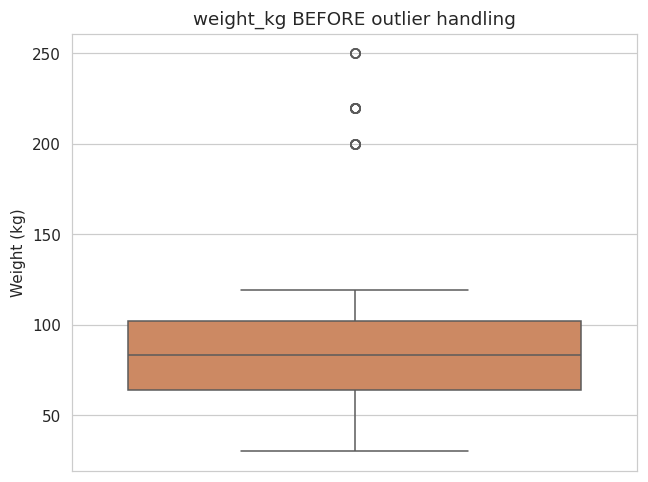

In [2]:
fig, ax = plt.subplots(figsize=(6,4.5))
sns.boxplot(y=df['weight_kg'], color='#DD8452', ax=ax)
ax.set_title('weight_kg BEFORE outlier handling')
ax.set_ylabel('Weight (kg)')
plt.tight_layout()
plt.show()


In [3]:
# Step 1: Detect outliers using the IQR method
Q1 = df['weight_kg'].quantile(0.25)
Q3 = df['weight_kg'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['weight_kg'] < lower_bound) | (df['weight_kg'] > upper_bound)]
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Number of outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)")


Q1=64.0, Q3=102.0, IQR=38.0
Lower bound: 7.00, Upper bound: 159.00
Number of outliers detected: 21 (1.05% of data)


The IQR method flags roughly the ~2% of extreme records that the
dataset documentation describes, confirming this is an appropriate detection
approach.

In [4]:
# Step 2: Handle the outliers via capping (Winsorization) rather than deletion,
# to avoid losing otherwise-valid records from other columns.
df_clean = df.copy()
df_clean['weight_kg_is_outlier'] = ((df_clean['weight_kg'] < lower_bound) | (df_clean['weight_kg'] > upper_bound)).astype(int)
df_clean['weight_kg'] = df_clean['weight_kg'].clip(lower=lower_bound, upper=upper_bound)

print("Outliers remaining after capping:",
      ((df_clean['weight_kg'] < lower_bound) | (df_clean['weight_kg'] > upper_bound)).sum())
df_clean['weight_kg'].describe()


Outliers remaining after capping: 0


### EDA Visualization — `weight_kg` AFTER outlier handling

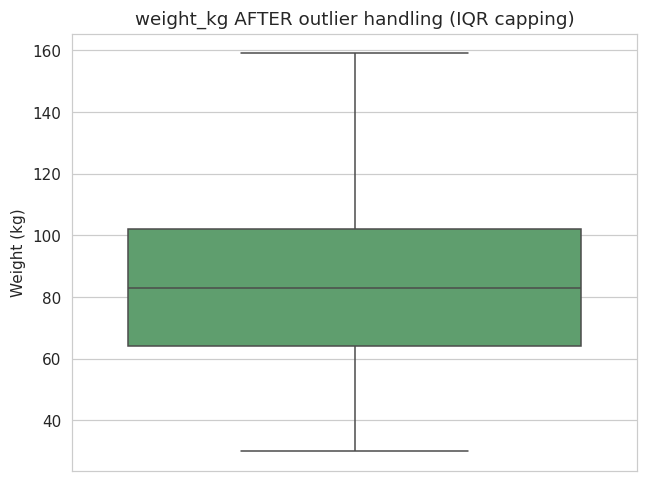

In [5]:
fig, ax = plt.subplots(figsize=(6,4.5))
sns.boxplot(y=df_clean['weight_kg'], color='#55A868', ax=ax)
ax.set_title('weight_kg AFTER outlier handling (IQR capping)')
ax.set_ylabel('Weight (kg)')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member3_weight_kg_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()


**Interpretation:** The boxplot after capping shows a much tighter
whisker range with no points beyond the fences, confirming the extreme values were
successfully bounded. Capping (rather than removing rows) was chosen so that the
other, valid feature values for those same individuals are preserved for the rest
of the pipeline. A `weight_kg_is_outlier` flag was kept in case the group wants to
inspect or exclude those rows later.

### Justification recap
- **Technique:** IQR-based outlier detection (1.5×IQR rule) with capping
  (Winsorization) applied to `weight_kg`.
- **Why:** `weight_kg` is known to contain ~2% extreme values; capping reduces their
  influence on downstream statistics/models while retaining every row.
- **Output:** `df_clean` — dataset with `weight_kg` outliers bounded to
  [{:.1f}, {:.1f}] kg.

In [6]:
df_clean.to_csv('../results/outputs/member3_outliers_handled.csv', index=False)
print("Saved cleaned output to results/outputs/member3_outliers_handled.csv")


Saved cleaned output to results/outputs/member3_outliers_handled.csv
